In [2]:

import json
import os
result_root_path = "../data/results"
result_models = {
    "LSTM": {
        "folder_path": result_root_path + "/Seq2Seq_LSTM",
        "training_time": json.load(open(os.path.join(result_root_path + "/Seq2Seq_LSTM", "training_time.json"), "r"))["train_time_sec"]
    },
   #"LSTM_BI": {
   #    "folder_path": result_root_path + "/Seq2Seq_LSTM_Bidirectional",
   #    "training_time": json.load(open(os.path.join(result_root_path + "/Seq2Seq_LSTM_Bidirectional", "training_time.json"), "r"))["train_time_sec"]
   #},
   #"TCN": {
   #    "folder_path": result_root_path + "/Seq2Seq_TCN",
   #    "training_time": json.load(open(os.path.join(result_root_path + "/Seq2Seq_TCN", "training_time.json"), "r"))["train_time_sec"]
   #},
   #"TCN_BI": {
   #    "folder_path": result_root_path + "/Seq2Seq_TCN_Bidirectional",
   #    "training_time": json.load(open(os.path.join(result_root_path + "/Seq2Seq_TCN_Bidirectional", "training_time.json"), "r"))["train_time_sec"]    
   #}
}
period_info = json.load(open(os.path.join("../data/", "complete_periods_summary.json"), "r"))

/home/zino/projects/wind-speed-forescasting/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


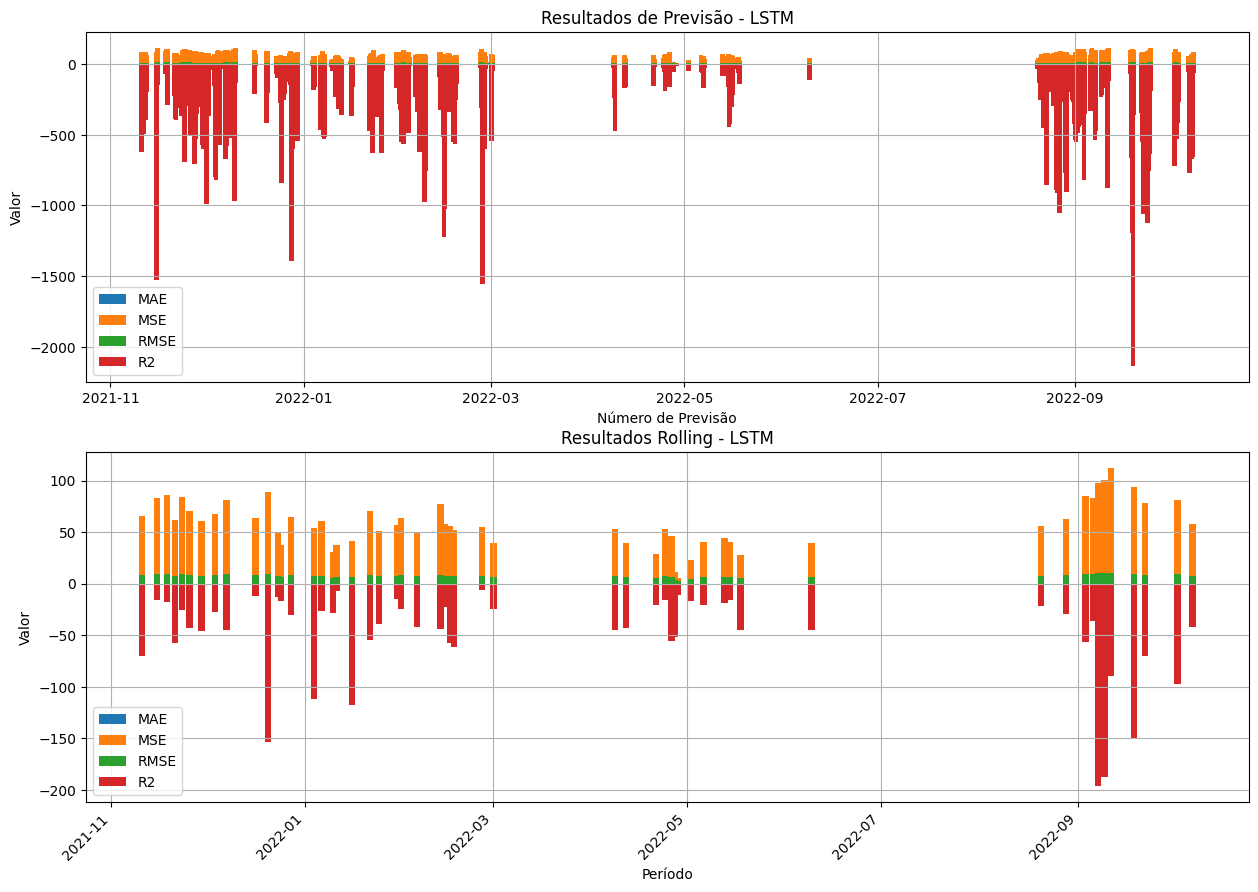

In [3]:
import os
import matplotlib.pyplot as plt
import pandas as pd
def plot_results(model_name, folder_path):
    plt.figure(figsize=(15, 10))
    rolling_results = pd.read_csv(os.path.join(folder_path, "rolling_results.csv"))
    rolling_results["period_start"] = [pd.to_datetime(period_info[(period)]["start"]) for period in rolling_results["period"]]
    prediction_results = pd.read_csv(os.path.join(folder_path, "prediction_results.csv"))
    prediction_results["window_start"] = pd.to_datetime(prediction_results["window_start"])
    prediction_results["window_month"] = prediction_results["window_start"].dt.to_period('M')
    #prediction_results = prediction_results.set_index("window_start")

    #prediction_per_month = prediction_results.groupby("window_month").mean()

    plt.subplot(2, 1, 1)
    plt.bar(prediction_results["window_start"], prediction_results["mae"] , width=1.5, label="MAE")
    plt.bar(prediction_results["window_start"], prediction_results["mse"] , width=1.5, label="MSE")
    plt.bar(prediction_results["window_start"], prediction_results["rmse"], width=1.5, label="RMSE")
    plt.bar(prediction_results["window_start"], prediction_results["r2"]  , width=1.5, label="R2")
    plt.title(f"Resultados de Previsão - {model_name}")
    plt.xlabel("Número de Previsão")
    plt.ylabel("Valor")
    plt.legend()
    plt.grid()

    plt.subplot(2, 1, 2)
    plt.bar(rolling_results["period_start"], rolling_results["mae"] , width=2, label="MAE")
    plt.bar(rolling_results["period_start"], rolling_results["mse"] , width=2, label="MSE")
    plt.bar(rolling_results["period_start"], rolling_results["rmse"], width=2, label="RMSE")
    plt.bar(rolling_results["period_start"], rolling_results["r2"]  , width=2, label="R2")
    plt.title(f"Resultados Rolling - {model_name}")
    plt.xlabel("Período")
    plt.ylabel("Valor")
    plt.xticks(rotation=45, ha='right')
    plt.legend()
    plt.grid()

    plt.show()

for model_name, model_info in result_models.items():
    plot_results(model_name, model_info["folder_path"])

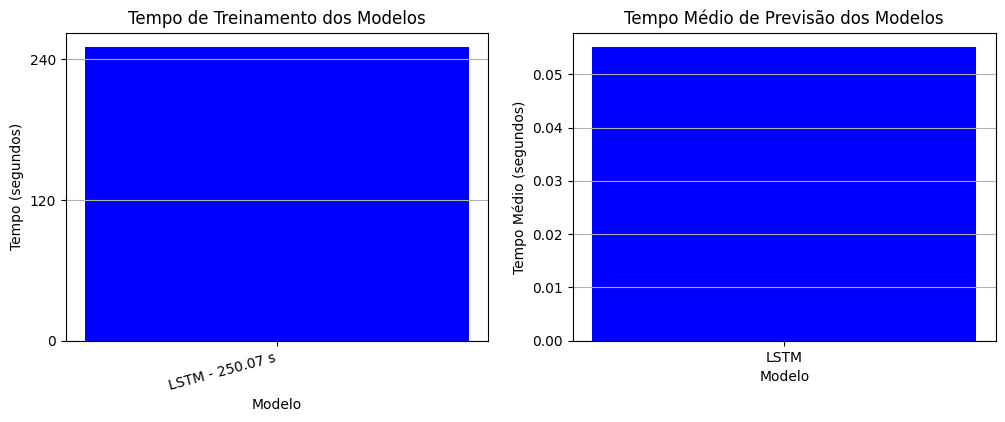

In [4]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
model_names = [(model_name + " - " + f"{model_info['training_time']:.2f} s") for model_name, model_info in result_models.items()]
training_times = [model_info["training_time"] for model_info in result_models.values()]
plt.bar(model_names, training_times, color=['blue', 'orange', 'green'])
plt.title("Tempo de Treinamento dos Modelos")
plt.xlabel("Modelo")
plt.ylabel("Tempo (segundos)")
plt.yticks(range(0, int(max(training_times))+60, 120))  # Ajusta os ticks do eixo y
plt.xticks(rotation=15, ha='right')  # Rotaciona os rótulos do eixo x para melhor visualização
plt.grid(axis='y')

plt.subplot(1, 2, 2)
prediction_times = []
for model_info in result_models.values():
    prediction_results = pd.read_csv(os.path.join(model_info["folder_path"], "prediction_results.csv"))
    prediction_times.append(prediction_results["prediction_time_sec"].mean())
model_names = [model_name for model_name, model_info in result_models.items()]
plt.bar(model_names, prediction_times, color=['blue', 'orange', 'green'])
plt.title("Tempo Médio de Previsão dos Modelos")
plt.xlabel("Modelo")
plt.ylabel("Tempo Médio (segundos)")
plt.grid(axis='y')

plt.show()

In [5]:
def return_metrics(model_name, folder_path):
    rolling_results = pd.read_csv(os.path.join(folder_path, "rolling_results.csv"))
    prediction_results = pd.read_csv(os.path.join(folder_path, "prediction_results.csv"))

    metrics = {
        "model_name": model_name,
        "rolling_mae": rolling_results["mae"].mean(),
        "rolling_mse": rolling_results["mse"].mean(),
        "rolling_rmse": rolling_results["rmse"].mean(),
        "rolling_r2": rolling_results["r2"].mean(),
        "prediction_mae": prediction_results["mae"].mean(),
        "prediction_mse": prediction_results["mse"].mean(),
        "prediction_rmse": prediction_results["rmse"].mean(),
        "prediction_r2": prediction_results["r2"].mean(),
        "average_prediction_time_sec": prediction_results["prediction_time_sec"].mean()
    }

    return metrics

results_df = pd.DataFrame([return_metrics(model_name, model_info["folder_path"]) for model_name, model_info in result_models.items()])
results_df = results_df.sort_values(by="rolling_mae").reset_index(drop=True)
rolling_df = results_df[["model_name", "rolling_mae", "rolling_mse", "rolling_rmse", "rolling_r2", "average_prediction_time_sec"]]
prediction_df = results_df[["model_name", "prediction_mae", "prediction_mse", "prediction_rmse", "prediction_r2", "average_prediction_time_sec"]]

rolling_df = rolling_df.rename(columns={
    "model_name": "Modelo",
    "rolling_mae": "MAE",
    "rolling_mse": "MSE",
    "rolling_rmse": "RMSE",
    "rolling_r2": "R2",
    "average_prediction_time_sec": "Tempo Médio de Previsão (s)"
})
prediction_df = prediction_df.rename(columns={
    "model_name": "Modelo",
    "prediction_mae": "MAE",
    "prediction_mse": "MSE",
    "prediction_rmse": "RMSE",
    "prediction_r2": "R2",
    "average_prediction_time_sec": "Tempo Médio de Previsão (s)"
})

display(rolling_df)
display(prediction_df)

,Modelo,MAE,MSE,RMSE,R2,Tempo Médio de Previsão (s)
0,LSTM,7.379511,58.863934,7.508634,-48.891532,0.055054


,Modelo,MAE,MSE,RMSE,R2,Tempo Médio de Previsão (s)
0,LSTM,7.564818,60.149386,7.63416,-161.380942,0.055054
